In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
from ucimlrepo import fetch_ucirepo

cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

## Feature Engineering

In [12]:
X = X.copy()

# BMI category: 0=underweight, 1=normal, 2=overweight, 3=obese
X['BMI_Category'] = pd.cut(X['BMI'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(float)

# Interaction features
X['BMI_HighBP']   = X['BMI'] * X['HighBP']
X['Age_GenHlth']  = X['Age'] * X['GenHlth']
X['PhysAct_BMI']  = X['PhysActivity'] * X['BMI']

print("New features added:", ['BMI_Category', 'BMI_HighBP', 'Age_GenHlth', 'PhysAct_BMI'])
print("Total features:", X.shape[1])

New features added: ['BMI_Category', 'BMI_HighBP', 'Age_GenHlth', 'PhysAct_BMI']
Total features: 25


In [13]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(random_state=42)
X_res, y_res = smoteenn.fit_resample(X, y.values.ravel())

print(f"Before SMOTEENN — 0: {(y.values.ravel()==0).sum()}, 1: {(y.values.ravel()==1).sum()}")
print(f"After  SMOTEENN — 0: {(y_res==0).sum()}, 1: {(y_res==1).sum()}")

Before SMOTEENN — 0: 218334, 1: 35346
After  SMOTEENN — 0: 137338, 1: 203523


# CDC Diabetes Prediction — XGBoost & Neural Network

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

range_features = [
    'BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income', 'GenHlth',
    'BMI_Category', 'BMI_HighBP', 'Age_GenHlth', 'PhysAct_BMI'
]

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

preprocessor = ColumnTransformer(transformers=[
    ('scale',       StandardScaler(), range_features),
    ('passthrough', 'passthrough',    binary_features)
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Class balance — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")

Train size: (272688, 25), Test size: (68173, 25)
Class balance — 0: 109870, 1: 162818


## XGBoost

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Subsample for faster tuning
from sklearn.model_selection import cross_val_score
import xgboost as xgb

X_tune = X_train.iloc[:50000]
y_tune = y_train[:50000]

def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'auc', 'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X_tune, y_tune, cv=3, scoring='roc_auc').mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=20)

print("Best XGBoost params:", xgb_study.best_params)
print(f"Best CV AUC: {xgb_study.best_value:.4f}")

Best XGBoost params: {'n_estimators': 301, 'max_depth': 8, 'learning_rate': 0.07334343704119682, 'subsample': 0.908645308707096, 'colsample_bytree': 0.968273399956538, 'min_child_weight': 3}
Best CV AUC: 0.9540


In [16]:
xgb_model = xgb.XGBClassifier(
    **xgb_study.best_params,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

[0]	validation_0-auc:0.93046
[50]	validation_0-auc:0.94867
[100]	validation_0-auc:0.95440
[150]	validation_0-auc:0.95837
[200]	validation_0-auc:0.96119
[250]	validation_0-auc:0.96340
[300]	validation_0-auc:0.96500

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.89      0.86      0.88     27468
           1       0.91      0.93      0.92     40705

    accuracy                           0.90     68173
   macro avg       0.90      0.90      0.90     68173
weighted avg       0.90      0.90      0.90     68173

ROC-AUC: 0.9650


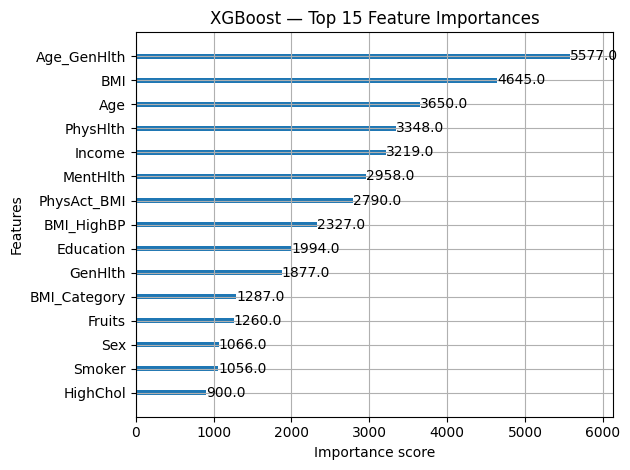

In [17]:
# XGBoost feature importance
xgb.plot_importance(xgb_model, max_num_features=15)
plt.title("XGBoost — Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## Neural Network (NLP)

## CatBoost

In [18]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold

def cat_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 600),
        'depth':         trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1, 10),
        'eval_metric': 'AUC', 'random_seed': 42, 'verbose': 0
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for train_idx, val_idx in skf.split(X_tune, y_tune):
        X_tr, X_val = X_tune.iloc[train_idx], X_tune.iloc[val_idx]
        y_tr, y_val = y_tune[train_idx], y_tune[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=binary_features)
        aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    return np.mean(aucs)

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=20)

print("Best CatBoost params:", cat_study.best_params)
print(f"Best CV AUC: {cat_study.best_value:.4f}")

Best CatBoost params: {'iterations': 468, 'depth': 8, 'learning_rate': 0.10093948678709709, 'l2_leaf_reg': 3.155372739775225}
Best CV AUC: 0.9536


In [19]:
catboost_model = CatBoostClassifier(
    **cat_study.best_params,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=50
)

catboost_model.fit(
    X_train, y_train,
    cat_features=binary_features,
    eval_set=(X_test, y_test)
)

y_pred_cat = catboost_model.predict(X_test)
y_prob_cat = catboost_model.predict_proba(X_test)[:, 1]

print("\n=== CatBoost Results ===")
print(classification_report(y_test, y_pred_cat))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_cat):.4f}")

0:	test: 0.9186115	best: 0.9186115 (0)	total: 51.3ms	remaining: 24s
50:	test: 0.9459458	best: 0.9459458 (50)	total: 3.08s	remaining: 25.2s
100:	test: 0.9512893	best: 0.9512893 (100)	total: 6.57s	remaining: 23.9s
150:	test: 0.9550689	best: 0.9550689 (150)	total: 9.75s	remaining: 20.5s
200:	test: 0.9572187	best: 0.9572187 (200)	total: 12.9s	remaining: 17.2s
250:	test: 0.9588683	best: 0.9588683 (250)	total: 16s	remaining: 13.8s
300:	test: 0.9602829	best: 0.9602829 (300)	total: 19.2s	remaining: 10.6s
350:	test: 0.9613071	best: 0.9613071 (350)	total: 22.2s	remaining: 7.4s
400:	test: 0.9621825	best: 0.9621825 (400)	total: 25.9s	remaining: 4.33s
450:	test: 0.9630309	best: 0.9630309 (450)	total: 29.2s	remaining: 1.1s
467:	test: 0.9632603	best: 0.9632603 (467)	total: 30.3s	remaining: 0us

bestTest = 0.9632602587
bestIteration = 467


=== CatBoost Results ===
              precision    recall  f1-score   support

           0       0.89      0.86      0.88     27468
           1       0.91      

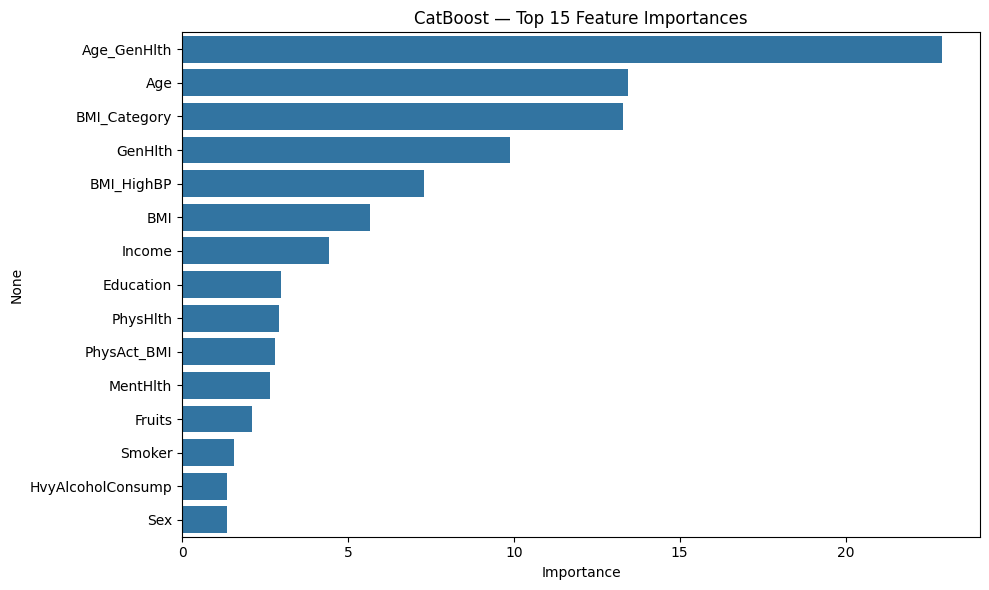

In [20]:
# CatBoost feature importance
feat_imp = pd.Series(
    catboost_model.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
plt.title("CatBoost — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Neural Network Results ===")
print(classification_report(y_test, y_pred_mlp))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp):.4f}")

Iteration 1, loss = 0.31521299
Validation score: 0.866382
Iteration 2, loss = 0.29437810
Validation score: 0.876682
Iteration 3, loss = 0.28506797
Validation score: 0.882887
Iteration 4, loss = 0.27935711
Validation score: 0.883384
Iteration 5, loss = 0.27435916
Validation score: 0.881697
Iteration 6, loss = 0.27079461
Validation score: 0.887046
Iteration 7, loss = 0.26633483
Validation score: 0.886403
Iteration 8, loss = 0.26315876
Validation score: 0.886860
Iteration 9, loss = 0.25917240
Validation score: 0.890027
Iteration 10, loss = 0.25595971
Validation score: 0.889969
Iteration 11, loss = 0.25171151
Validation score: 0.890905
Iteration 12, loss = 0.24823595
Validation score: 0.890749
Iteration 13, loss = 0.24457549
Validation score: 0.890382
Iteration 14, loss = 0.24104820
Validation score: 0.893017
Iteration 15, loss = 0.23713118
Validation score: 0.891361
Iteration 16, loss = 0.23288421
Validation score: 0.891749
Iteration 17, loss = 0.22962274
Validation score: 0.890662
Iterat

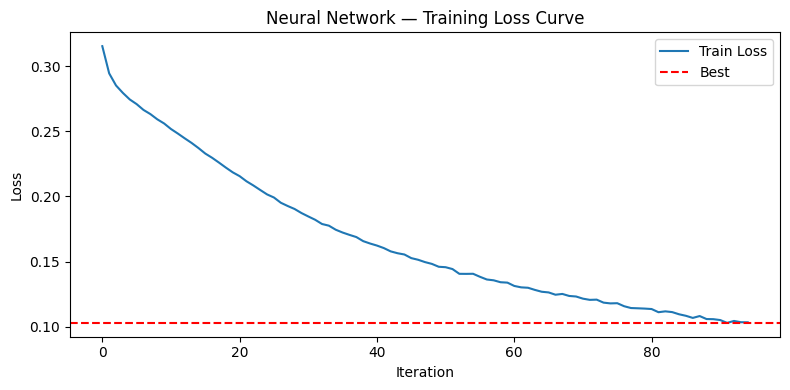

In [22]:
# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, label='Train Loss')
if mlp_model.best_validation_score_:
    plt.axhline(y=min(mlp_model.loss_curve_), color='r', linestyle='--', label='Best')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural Network — Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison

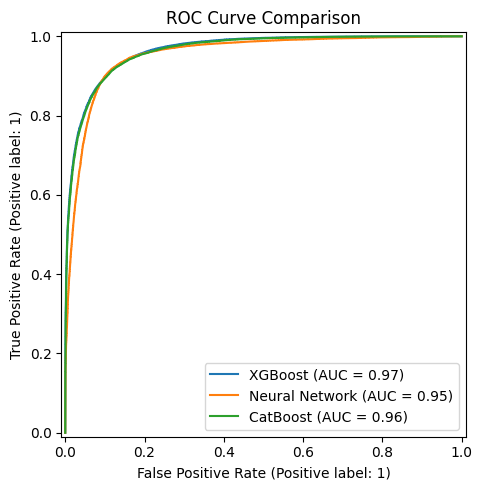

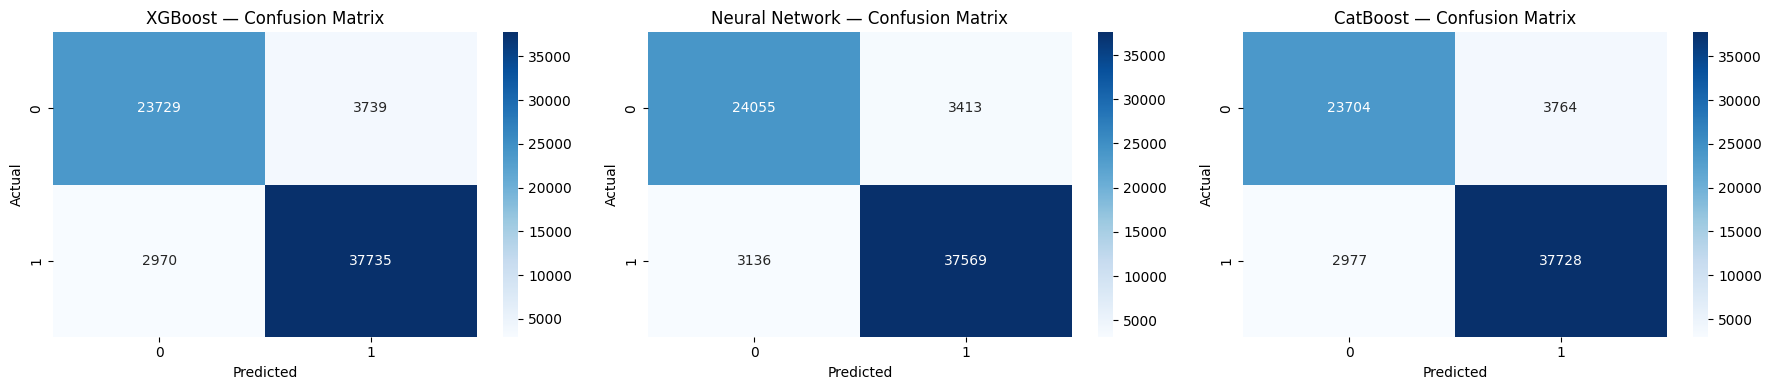


=== AUC-ROC Summary ===
XGBoost:        0.9650
Neural Network: 0.9535
CatBoost:       0.9633


In [23]:
from sklearn.metrics import RocCurveDisplay

# ROC Curve — all 3 models
fig, ax = plt.subplots(figsize=(8, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_mlp, name="Neural Network", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_cat, name="CatBoost", ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

# Confusion matrices — all 3 models
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax2, y_pred, title in zip(
    axes2,
    [y_pred_xgb, y_pred_mlp, y_pred_cat],
    ["XGBoost", "Neural Network", "CatBoost"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title(f"{title} — Confusion Matrix")
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n=== AUC-ROC Summary ===")
print(f"XGBoost:        {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Neural Network: {roc_auc_score(y_test, y_prob_mlp):.4f}")
print(f"CatBoost:       {roc_auc_score(y_test, y_prob_cat):.4f}")

## Threshold Tuning

XGBoost — best threshold: 0.48, F1: 0.9191
CatBoost — best threshold: 0.44, F1: 0.9183
Neural Network — best threshold: 0.37, F1: 0.9208


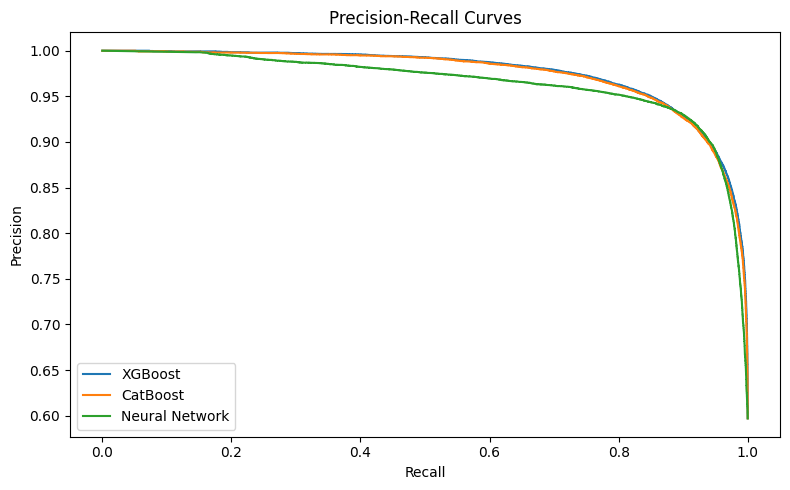

In [24]:
from sklearn.metrics import f1_score, precision_recall_curve

def best_threshold(y_true, y_prob, model_name):
    thresholds = np.arange(0.2, 0.7, 0.01)
    f1_scores  = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    best_t     = thresholds[np.argmax(f1_scores)]
    best_f1    = max(f1_scores)
    print(f"{model_name} — best threshold: {best_t:.2f}, F1: {best_f1:.4f}")
    return best_t

thresh_xgb = best_threshold(y_test, y_prob_xgb, "XGBoost")
thresh_cat = best_threshold(y_test, y_prob_cat, "CatBoost")
thresh_mlp = best_threshold(y_test, y_prob_mlp, "Neural Network")

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 5))
for y_prob, name in [(y_prob_xgb, "XGBoost"), (y_prob_cat, "CatBoost"), (y_prob_mlp, "Neural Network")]:
    p, r, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(r, p, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend()
plt.tight_layout()
plt.show()

## Ensemble

In [25]:
# Weighted average ensemble (CatBoost weighted higher as best performer)
y_prob_ensemble = (y_prob_xgb * 0.35 + y_prob_cat * 0.40 + y_prob_mlp * 0.25)

# Find best threshold for ensemble
thresh_ens = best_threshold(y_test, y_prob_ensemble, "Ensemble")
y_pred_ensemble = (y_prob_ensemble >= thresh_ens).astype(int)

print("\n=== Ensemble Results (tuned threshold) ===")
print(classification_report(y_test, y_pred_ensemble))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ensemble):.4f}")

# Final summary
print("\n=== Final AUC-ROC Summary ===")
print(f"XGBoost (thresh={thresh_xgb:.2f}):        {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"CatBoost (thresh={thresh_cat:.2f}):       {roc_auc_score(y_test, y_prob_cat):.4f}")
print(f"Neural Network (thresh={thresh_mlp:.2f}): {roc_auc_score(y_test, y_prob_mlp):.4f}")
print(f"Ensemble (thresh={thresh_ens:.2f}):       {roc_auc_score(y_test, y_prob_ensemble):.4f}")

Ensemble — best threshold: 0.48, F1: 0.9268

=== Ensemble Results (tuned threshold) ===
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     27468
           1       0.91      0.94      0.93     40705

    accuracy                           0.91     68173
   macro avg       0.91      0.90      0.91     68173
weighted avg       0.91      0.91      0.91     68173

ROC-AUC: 0.9688

=== Final AUC-ROC Summary ===
XGBoost (thresh=0.48):        0.9650
CatBoost (thresh=0.44):       0.9633
Neural Network (thresh=0.37): 0.9535
Ensemble (thresh=0.48):       0.9688


## Save Models

In [26]:
import pickle
import os

os.makedirs('models', exist_ok=True)

models = {
    'models/xgboost_model.pkl':    xgb_model,
    'models/catboost_model.pkl':   catboost_model,
    'models/mlp_model.pkl':        mlp_model,
    'models/preprocessor.pkl':     preprocessor,
}

for path, obj in models.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"Saved: {path}")

print("\nTo load a model:")
print("  with open('models/xgboost_model.pkl', 'rb') as f:")

Saved: models/xgboost_model.pkl
Saved: models/catboost_model.pkl
Saved: models/mlp_model.pkl
Saved: models/preprocessor.pkl

To load a model:
  with open('models/xgboost_model.pkl', 'rb') as f:
